# Stress Test: Slow Grind Up, Never Triggers Reset

**Scenario:** ETH grinds up toward 20% ITM threshold repeatedly but never quite touches it. Pulls back each time. Hyperliquid: shorts receive funding (income, not cost). No resets fire.

Perp bleeds on the upward drift but funding income partially offsets. Tests how much funding income is needed to stay positive.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ────────────────────────────────────────────────────────────────
SIGMA        = 0.60
T_MODEL      = 1.0
STRIKE_OTM   = 0.10
RESET_ITM    = 0.20
FUNDING_RATE = 0.10   # Hyperliquid: shorts receive funding (income)
NOTIONAL     = 1.0

def bs_delta(S, K, T, sigma, r=0.0):
    if T <= 0:
        return 1.0 if S >= K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def bs_price(S, K, T, sigma, r=0.0):
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

In [2]:
# ── Synthetic price path ───────────────────────────────────────────────────────
# 4 cycles of: grind up to ~19.5% ITM over ~45 days, pull back over ~15 days
# Total: ~240 days (~8 months)

np.random.seed(42)
S0     = 2000.0
strike = S0 * (1 + STRIKE_OTM)  # $2,200
peak   = strike * (1 + RESET_ITM - 0.005)  # $2,635 — just below reset
trough = S0 * 1.05               # $2,100 — mild pullback

def grind_leg(start, end, days, noise=0.012):
    """Smooth trend from start to end with small daily noise."""
    trend = np.linspace(start, end, days)
    noise_arr = np.random.normal(0, noise, days)
    # cumulative noise dampened so endpoint is preserved
    noise_arr -= noise_arr.mean()
    prices = trend * (1 + noise_arr)
    prices[0]  = start
    prices[-1] = end
    return prices

segments = []
for _ in range(4):
    segments.append(grind_leg(trough if segments else S0, peak, 45))
    segments.append(grind_leg(peak, trough, 15))

path = np.concatenate(segments)
dates = pd.date_range(start='2024-01-01', periods=len(path), freq='D')
prices = pd.Series(path, index=dates, name='price')
prices.index.name = 'date'

print(f'Days: {len(prices)}')
print(f'Start: ${prices.iloc[0]:,.0f}  |  End: ${prices.iloc[-1]:,.0f}')
print(f'Max: ${prices.max():,.0f}  |  Strike: ${strike:,.0f}  |  Reset level: ${peak:,.0f}')
print(f'Max ITM: {(prices.max()/strike - 1)*100:.1f}%  (reset fires at 20%)')

Days: 240
Start: $2,000  |  End: $2,100
Max: $2,650  |  Strike: $2,200  |  Reset level: $2,629
Max ITM: 20.5%  (reset fires at 20%)


In [3]:
# ── Backtest engine ────────────────────────────────────────────────────────────
def run_backtest(prices, t_model=T_MODEL, sigma=SIGMA, funding_rate=FUNDING_RATE):
    dates  = prices.index
    spots  = prices.values
    n      = len(spots)
    strike       = spots[0] * (1 + STRIKE_OTM)
    perp_pos     = -bs_delta(spots[0], strike, t_model, sigma) * NOTIONAL
    cash_pnl     = 0.0
    funding_received = 0.0
    resets       = []
    daily        = []
    for i in range(1, n):
        S_prev = spots[i - 1]
        S      = spots[i]
        fund_income      = funding_rate * abs(perp_pos) * S / 365
        cash_pnl        += fund_income
        funding_received += fund_income
        new_delta  = bs_delta(S, strike, t_model, sigma)
        cash_pnl  += perp_pos * (S - S_prev)
        perp_pos   = -new_delta * NOTIONAL
        if S / strike - 1 >= RESET_ITM:
            intrinsic  = (S - strike) * NOTIONAL
            cash_pnl  += intrinsic
            old_strike = strike
            strike     = S * (1 + STRIKE_OTM)
            perp_pos   = -bs_delta(S, strike, t_model, sigma) * NOTIONAL
            resets.append({'date': dates[i], 'spot': S,
                           'old_strike': old_strike, 'new_strike': strike,
                           'intrinsic': intrinsic})
        opt_val = bs_price(S, strike, t_model, sigma)
        daily.append({'date': dates[i], 'spot': S, 'strike': strike,
                      'delta': bs_delta(S, strike, t_model, sigma),
                      'opt_value': opt_val, 'cash_pnl': cash_pnl,
                      'total_pnl': cash_pnl + opt_val * NOTIONAL,
                      'funding_received': funding_received,
                      'perp_pnl': cash_pnl - funding_received})
    return pd.DataFrame(daily).set_index('date'), pd.DataFrame(resets)

results, resets = run_backtest(prices)

f = results.iloc[-1]
print(f'Cash P&L:       ${f["cash_pnl"]:+,.2f}')
print(f'  Perp P&L:     ${f["cash_pnl"] - f["funding_received"]:+,.2f}')
print(f'  Funding received: +${f["funding_received"]:,.2f}')
print(f'Option mark:    ${f["opt_value"]:+,.2f}  (unrealised)')
print(f'Resets fired:   {len(resets)}')
print(f'ETH drift:      {(prices.iloc[-1]/prices.iloc[0]-1)*100:+.1f}%')

Cash P&L:       $+436.98
  Perp P&L:     $+350.42
  Funding received: +$86.56
Option mark:    $+268.39  (unrealised)
Resets fired:   1
ETH drift:      +5.0%


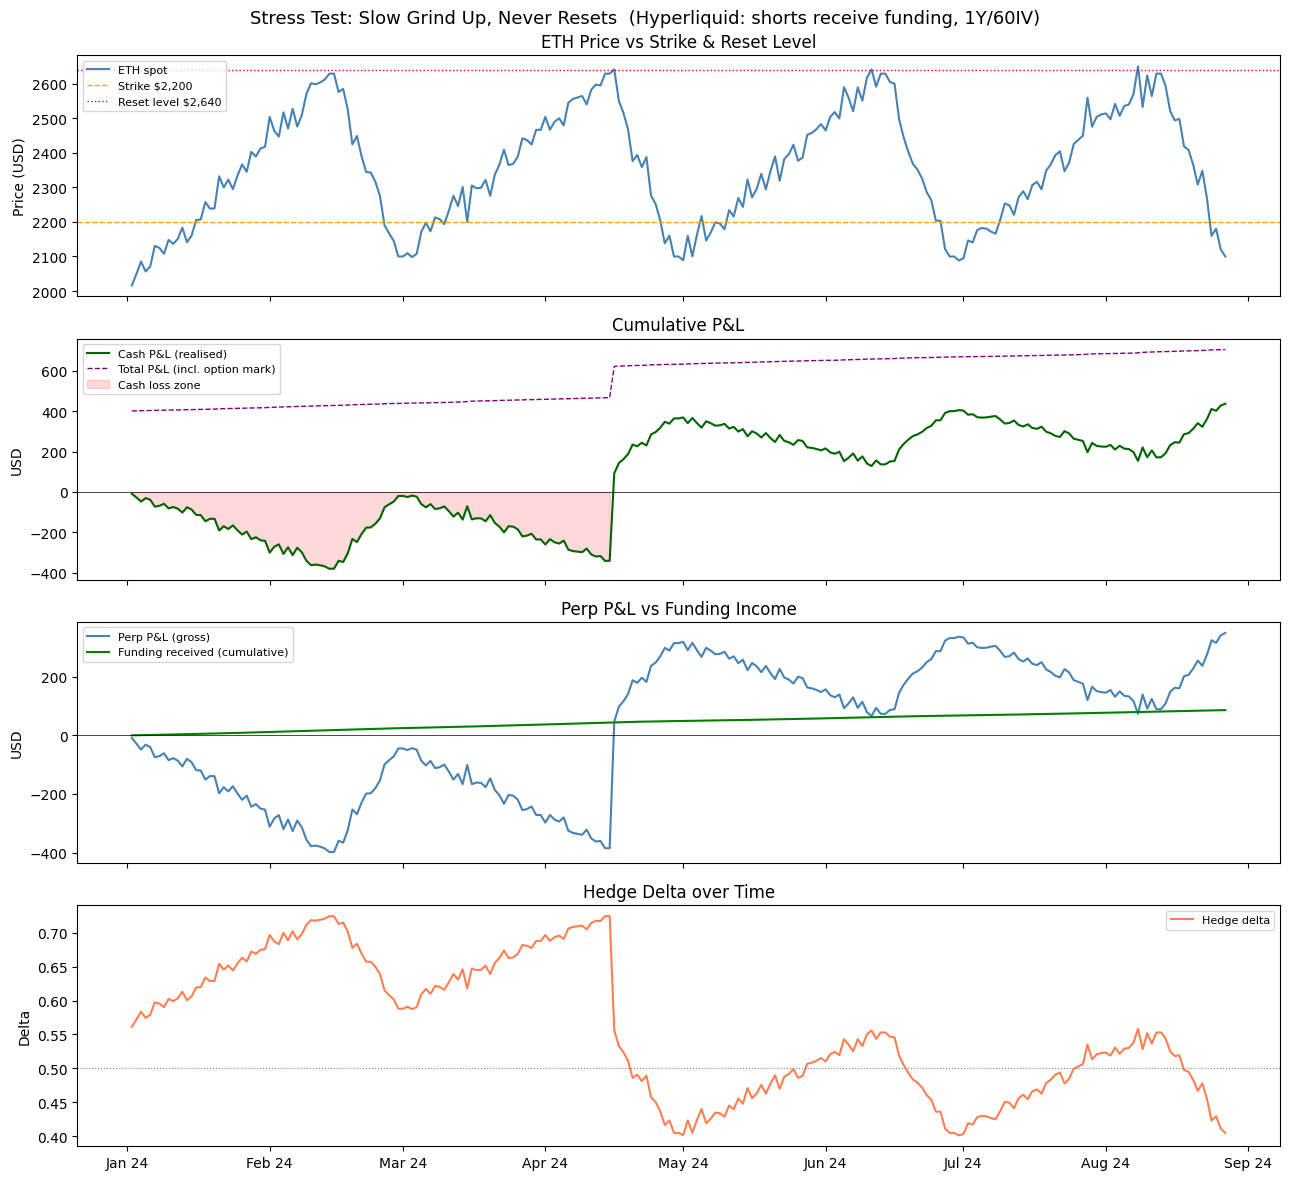

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
fig.suptitle('Stress Test: Slow Grind Up, Never Resets  (Hyperliquid: shorts receive funding, 1Y/60IV)', fontsize=13)
ax1, ax2, ax3, ax4 = axes

# Price path + strike + reset level
ax1.plot(results.index, results['spot'], color='steelblue', label='ETH spot')
ax1.axhline(results['strike'].iloc[0], color='orange', linestyle='--', linewidth=1, label=f'Strike ${results["strike"].iloc[0]:,.0f}')
ax1.axhline(results['strike'].iloc[0] * 1.20, color='red', linestyle=':', linewidth=1, label=f'Reset level ${results["strike"].iloc[0]*1.20:,.0f}')
ax1.set_ylabel('Price (USD)'); ax1.legend(fontsize=8)
ax1.set_title('ETH Price vs Strike & Reset Level')

# P&L breakdown
ax2.plot(results.index, results['cash_pnl'], color='darkgreen', linewidth=1.5, label='Cash P&L (realised)')
ax2.plot(results.index, results['total_pnl'], color='purple', linestyle='--', linewidth=1, label='Total P&L (incl. option mark)')
ax2.fill_between(results.index, results['cash_pnl'], 0,
                  where=results['cash_pnl'] < 0, color='red', alpha=0.15, label='Cash loss zone')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('USD'); ax2.legend(fontsize=8); ax2.set_title('Cumulative P&L')

# Perp P&L vs funding
gross_perp = results['cash_pnl'] - results['funding_received']
ax3.plot(results.index, gross_perp, color='steelblue', label='Perp P&L (gross)')
ax3.plot(results.index, results['funding_received'], color='green', label='Funding received (cumulative)')
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_ylabel('USD'); ax3.legend(fontsize=8); ax3.set_title('Perp P&L vs Funding Income')

# Delta
ax4.plot(results.index, results['delta'], color='coral', label='Hedge delta')
ax4.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
ax4.set_ylabel('Delta'); ax4.legend(fontsize=8); ax4.set_title('Hedge Delta over Time')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

plt.tight_layout()
plt.savefig('stresstest.png', dpi=150)
plt.show()

## Sensitivity: How much does funding income improve the strategy?
Sweep funding rate from 10% to 100% annualised on the same price path.

In [5]:
funding_rates = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 1.00]

print(f'  {"Funding":>8}  {"CashPnL":>10}  {"PerpPnL":>10}  {"FundingIncome":>14}')
print(f'  {"-"*8}  {"-"*10}  {"-"*10}  {"-"*12}')
for fr in funding_rates:
    res, _ = run_backtest(prices, funding_rate=fr)
    f = res.iloc[-1]
    perp = f['cash_pnl'] - f['funding_received']
    marker = ' <-- breakeven' if abs(f['cash_pnl']) < 50 else ('  NEGATIVE' if f['cash_pnl'] < 0 else '')
    print(f'  {fr*100:.0f}%      ${f["cash_pnl"]:>+9,.0f}  ${perp:>+9,.0f}  ${f["funding_received"]:>+13,.0f}{marker}')

   Funding     CashPnL     PerpPnL   FundingIncome
  --------  ----------  ----------  ------------
  10%      $     +437  $     +350  $          +87
  20%      $     +524  $     +350  $         +173
  30%      $     +610  $     +350  $         +260
  40%      $     +697  $     +350  $         +346
  50%      $     +783  $     +350  $         +433
  60%      $     +870  $     +350  $         +519
  75%      $   +1,000  $     +350  $         +649
  100%      $   +1,216  $     +350  $         +866
